# CNN Material Classification

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.5.1
CUDA available: True
CUDA device: Tesla V100S-PCIE-32GB
Using device: cuda


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

## Data Loading and Analysis

In [38]:
# Load the pickle files
data_train = pd.read_pickle("DamasconeANN.pkl")
data_validation = pd.read_pickle("DamasconeANN.pkl") 
data_test = pd.read_pickle("DamasconeBNN.pkl")

print(f"Train data shape: {data_train.shape}")
print(f"Validation data shape: {data_validation.shape}")
print(f"Test data shape: {data_test.shape}")

Train data shape: (6560, 32)
Validation data shape: (6560, 32)
Test data shape: (6557, 32)


In [39]:
F_name = "Fi"
P_name = "Pi2"
time_name = "time"

data_train["Pi2"] = data_train["Pi"]*10000
data_validation["Pi2"] = data_validation["Pi"]*10000
data_test["Pi2"] = data_test["Pi"]*10000



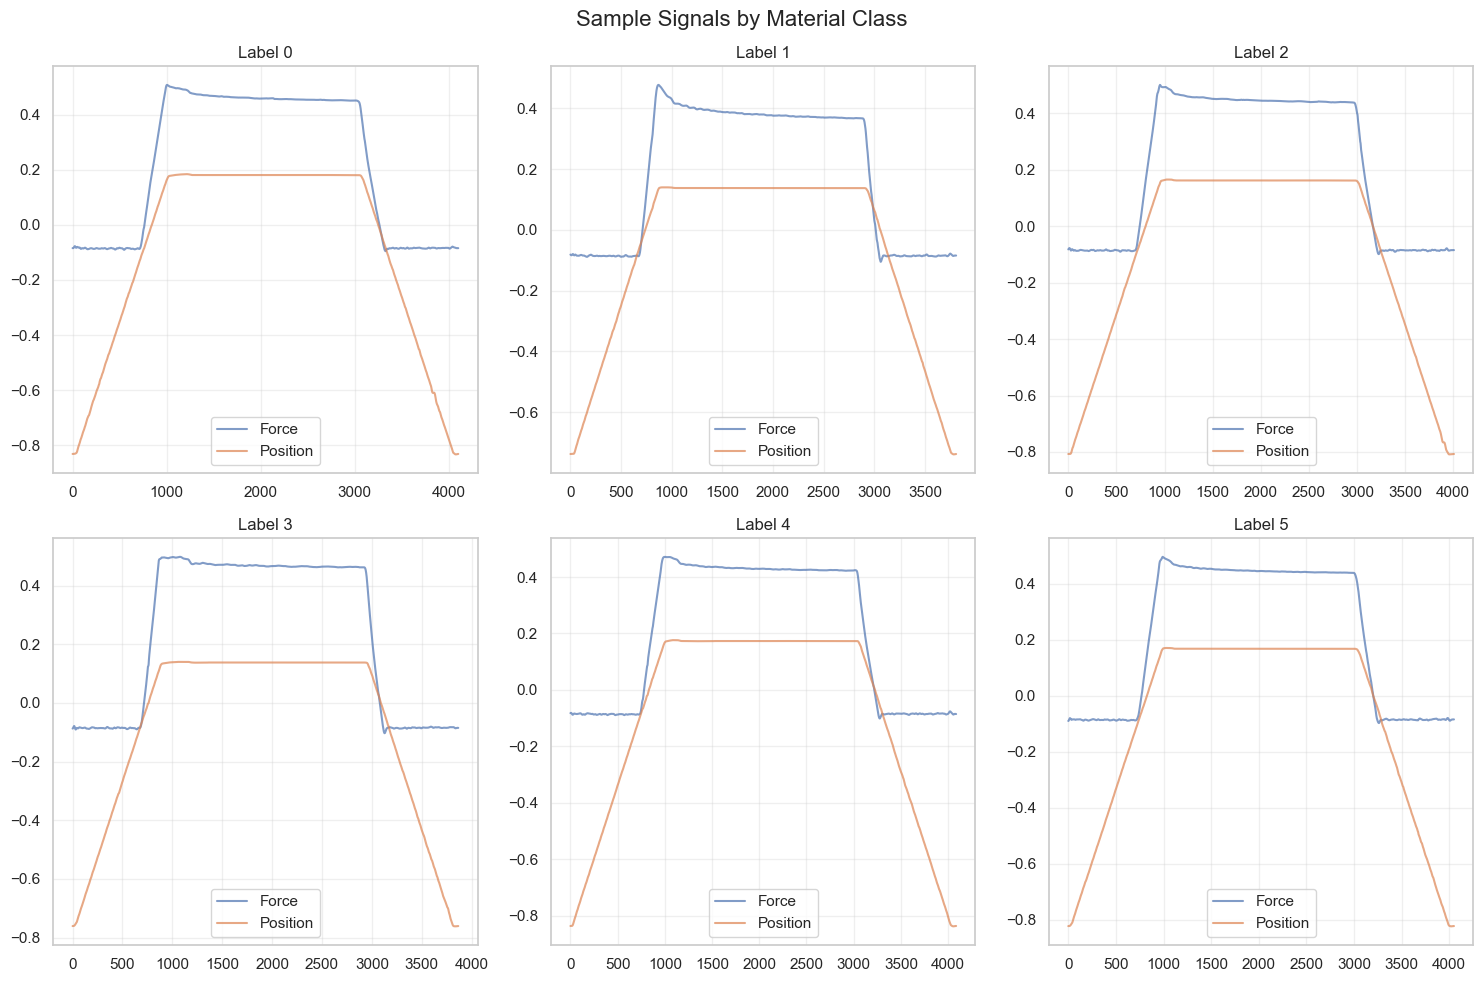

In [ ]:
# Visualize sample signals for each dataset
datasets_to_plot = [
    (data_train, "Training Set"),
    (data_validation, "Validation Set"),
    (data_test, "Test Set")
]

for dataset, dataset_name in datasets_to_plot:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Sample Signals by Material Class - {dataset_name}', fontsize=16)
    
    unique_labels = sorted(dataset['label'].unique())[:6]
    
    for i, label in enumerate(unique_labels):
        row = i // 3
        col = i % 3
        
        # Get random sample for this label
        samples_for_label = dataset[dataset['label'] == label]
        
        if len(samples_for_label) > 0:
            sample = samples_for_label.sample(n=1).iloc[0]
            
            fz_signal = np.array(sample[F_name])
            pz_signal = np.array(sample[P_name])
            
            axes[row, col].plot(fz_signal, label='Force', alpha=0.7)
            axes[row, col].plot(pz_signal, label='Position', alpha=0.7)
            axes[row, col].set_title(f'Label {label}')
            axes[row, col].legend()
            axes[row, col].grid(True, alpha=0.3)
        else:
            axes[row, col].text(0.5, 0.5, f'No data for label {label}', 
                               ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].set_title(f'Label {label}')
    
    plt.tight_layout()
    plt.show()

## Signal Preprocessing

In [22]:
def extract_signals_and_labels(df):
    """Extract signals and labels from DataFrame"""
    signals = []
    labels = []
    
    for idx, row in df.iterrows():
        if row["label"] != 0:
            fz_signal = np.array(row[F_name])
            pz_signal = np.array(row[P_name])
            
            # Filter: keep only where pz > 0
            mask = pz_signal > 0
            fz_signal = fz_signal[mask]
            pz_signal = pz_signal[mask]
            
            # Skip if no valid data points remain
            if len(fz_signal) == 0:
                continue
            
            # Stack signals to create 2-channel input
            signal = np.stack([fz_signal, pz_signal], axis=1)  # Shape: (time_steps, 2)
            
            signals.append(signal)
            labels.append(row['label'] -1)
    
    return signals, labels

# Extract signals from all datasets
tr_s, tr_l = extract_signals_and_labels(data_train)
val_s, val_l = extract_signals_and_labels(data_validation)
test_s, test_l = extract_signals_and_labels(data_test)

print(f"Extracted {len(tr_s)} training signals")
print(f"Extracted {len(val_s)} validation signals")
print(f"Extracted {len(test_s)} test signals")
print(f"Sample signal shape: {tr_s[0].shape}")

Extracted 1953 training signals
Extracted 1944 validation signals
Extracted 1944 test signals
Sample signal shape: (2366, 2)


In [23]:
# Analyze signal lengths
train_lengths = [len(signal) for signal in tr_s]
val_lengths = [len(signal) for signal in val_s]
test_lengths = [len(signal) for signal in test_s]

argmin_train = np.argmin(train_lengths)
argmax_train = np.argmax(train_lengths)
argmax_val = np.argmax(val_lengths)
argmax_test = -1 #np.argmax(test_lengths)

train_signals = [signal for i, signal in enumerate(tr_s) if i != argmin_train and i != argmax_train]
train_labels = [label for i, label in enumerate(tr_l) if i != argmin_train and i != argmax_train]

val_signals = [signal for i, signal in enumerate(val_s) if i != argmax_val]
val_labels = [label for i, label in enumerate(val_l) if i != argmax_val]

test_signals = [signal for i, signal in enumerate(test_s) if i != argmax_test]
test_labels = [label for i, label in enumerate(test_l) if i != argmax_test]

all_signals = train_signals + val_signals + test_signals
signal_lengths = [len(signal) for signal in all_signals]

train_lengths = [len(signal) for signal in train_signals]
val_lengths = [len(signal) for signal in val_signals]
test_lengths = [len(signal) for signal in test_signals]

print("=== SIGNAL LENGTH ANALYSIS ===")
print(f"Minimum signal length: {min(signal_lengths)}")
print(f"Maximum signal length: {max(signal_lengths)}")
print(f"Average signal length: {np.mean(signal_lengths):.1f}")
print(f"Median signal length: {np.median(signal_lengths):.1f}")
print(f"Standard deviation: {np.std(signal_lengths):.1f}")

# Show distribution by dataset
print("\n=== LENGTH DISTRIBUTION BY DATASET ===")
print(f"Training set - Min: {min(train_lengths)}, Max: {max(train_lengths)}, Avg: {np.mean(train_lengths):.1f}")
print(f"Validation set - Min: {min(val_lengths)}, Max: {max(val_lengths)}, Avg: {np.mean(val_lengths):.1f}")
print(f"Test set - Min: {min(test_lengths)}, Max: {max(test_lengths)}, Avg: {np.mean(test_lengths):.1f}")

=== SIGNAL LENGTH ANALYSIS ===
Minimum signal length: 2304
Maximum signal length: 2489
Average signal length: 2368.0
Median signal length: 2369.0
Standard deviation: 25.3

=== LENGTH DISTRIBUTION BY DATASET ===
Training set - Min: 2304, Max: 2489, Avg: 2367.2
Validation set - Min: 2304, Max: 2480, Avg: 2368.4
Test set - Min: 2304, Max: 2489, Avg: 2368.5


In [24]:
def pad_signals_to_max_length(signals, max_length):
    """Pad signals to the maximum length by appending the last value."""
    processed_signals = []
    for signal in signals:
        current_length = signal.shape[0]
        if current_length < max_length:
            pad_length = max_length - current_length
            last_value = signal[-1:, :]  # Get last value instead of first
            padding = np.repeat(last_value, pad_length, axis=0)
            processed_signal = np.vstack([signal, padding])  # Append instead of prepend
        else:
            processed_signal = signal
        processed_signals.append(processed_signal)
    return np.array(processed_signals)

# Find the maximum length among all signals
all_lengths = [len(signal) for signal in train_signals + val_signals + test_signals]
max_length = max(all_lengths)
print(f"Maximum signal length: {max_length}")

# Process all signals to fixed length
X_train = pad_signals_to_max_length(train_signals, max_length)
X_val = pad_signals_to_max_length(val_signals, max_length)
X_test = pad_signals_to_max_length(test_signals, max_length)

# Convert labels to arrays
y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"Processed data shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")

Maximum signal length: 2489
Processed data shapes:
X_train: (1951, 2489, 2)
X_val: (1943, 2489, 2)
X_test: (1944, 2489, 2)
y_train: (1951,)


In [25]:
# Prepare labels for classification
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))
print(f"Number of classes: {num_classes}")

# Compute class weights to handle imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

print(class_weights)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Class weights: {class_weights}")

# Apply standard scaling to each dataset independently
print("\n=== APPLYING STANDARD SCALING ===")
print("Scaling each dataset based on its own statistics...")

# Reshape for scaling: (samples, timesteps, channels) -> (samples * timesteps, channels)
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

# Create separate scalers for each dataset
scaler_train = StandardScaler()
scaler_val = StandardScaler()
scaler_test = StandardScaler()

# Fit and transform each dataset independently
X_train_scaled = scaler_train.fit_transform(X_train_reshaped)
X_val_scaled = scaler_val.fit_transform(X_val_reshaped)
X_test_scaled = scaler_test.fit_transform(X_test_reshaped)

# Reshape back to original shape
X_train = X_train_scaled.reshape(X_train.shape)
X_val = X_val_scaled.reshape(X_val.shape)
X_test = X_test_scaled.reshape(X_test.shape)

print(f"Train - Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"Val - Mean: {X_val.mean():.4f}, Std: {X_val.std():.4f}")
print(f"Test - Mean: {X_test.mean():.4f}, Std: {X_test.std():.4f}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)

y_train_tensor = torch.LongTensor(y_train).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"\nTensor shapes:")
print(f"X_train: {X_train_tensor.shape}")
print(f"y_train: {y_train_tensor.shape}")

Number of classes: 5
[1.00051282 0.99035533 1.02414698 0.9878481  0.99795396]
Class weights: [1.00051282 0.99035533 1.02414698 0.9878481  0.99795396]

=== APPLYING STANDARD SCALING ===
Scaling each dataset based on its own statistics...
Train - Mean: -0.0000, Std: 1.0000
Val - Mean: 0.0000, Std: 1.0000
Test - Mean: 0.0000, Std: 1.0000

Tensor shapes:
X_train: torch.Size([1951, 2489, 2])
y_train: torch.Size([1951])
Train - Mean: -0.0000, Std: 1.0000
Val - Mean: 0.0000, Std: 1.0000
Test - Mean: 0.0000, Std: 1.0000

Tensor shapes:
X_train: torch.Size([1951, 2489, 2])
y_train: torch.Size([1951])


## CNN Model Architecture

In [28]:
class SignalCNN(nn.Module):
    def __init__(self, input_length, input_channels, num_classes):
        super(SignalCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=27)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(kernel_size=4)
        self.dropout1 = nn.Dropout(0.0)
        # Second convolutional block
        self.conv2 = nn.Conv1d(16, 32, kernel_size=25)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(kernel_size=4)
        self.dropout2 = nn.Dropout(0.0)
        # Third convolutional block
        self.conv3 = nn.Conv1d(32, 64, kernel_size=21)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(kernel_size=2)
        self.dropout3 = nn.Dropout(0.0)
        # Fourth convolutional block
        self.conv4 = nn.Conv1d(64, 128, kernel_size=17)
        self.bn4 = nn.BatchNorm1d(128)
        self.pool4 = nn.MaxPool1d(kernel_size=2)
        self.dropout4 = nn.Dropout(0.2)
        # Fifth convolutional block
        self.conv5 = nn.Conv1d(128, 256, kernel_size=15)
        self.bn5 = nn.BatchNorm1d(256)
        self.pool5 = nn.MaxPool1d(kernel_size=2)
        self.dropout5 = nn.Dropout(0.2)
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(2)
        # Dense layers
        self.fc1 = nn.Linear(512, 256)
        self.bn6 = nn.BatchNorm1d(256)
        self.dropout6 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.dropout7 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, 32)
        self.dropout8 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, num_classes)
    def forward(self, x):
        # Input shape: (batch_size, sequence_length, channels)
        # Conv1d expects: (batch_size, channels, sequence_length)
        x = x.transpose(1, 2)
        # First conv block
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        # Second conv block
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        # Third conv block
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        # Fourth conv block
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        # Fifth conv block
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool5(x)
        x = self.dropout5(x)
        # Global average pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        # Dense layers
        x = F.relu(self.bn6(self.fc1(x)))
        x = self.dropout6(x)
        x = F.relu(self.fc2(x))
        x = self.dropout7(x)
        x = F.relu(self.fc3(x))
        x = self.dropout8(x)
        x = self.fc4(x)
        return x


# Create model
model = SignalCNN(max_length, 2, num_classes).to(device)

from torchinfo import summary
summary(model, 
        input_size=(1, max_length, 2),  # Correct input shape: (batch_size, sequence_length, channels)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=10,
        verbose=1,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
SignalCNN (SignalCNN)                    [1, 2489, 2]              [1, 5]                    --                        True
├─Conv1d (conv1)                         [1, 2, 2489]              [1, 16, 2463]             880                       True
├─BatchNorm1d (bn1)                      [1, 16, 2463]             [1, 16, 2463]             32                        True
├─MaxPool1d (pool1)                      [1, 16, 2463]             [1, 16, 615]              --                        --
├─Dropout (dropout1)                     [1, 16, 615]              [1, 16, 615]              --                        --
├─Conv1d (conv2)                         [1, 16, 615]              [1, 32, 591]              12,832                    True
├─BatchNorm1d (bn2)                      [1, 32, 591]              [1, 32, 591]              64                        True
├─MaxPo

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
SignalCNN (SignalCNN)                    [1, 2489, 2]              [1, 5]                    --                        True
├─Conv1d (conv1)                         [1, 2, 2489]              [1, 16, 2463]             880                       True
├─BatchNorm1d (bn1)                      [1, 16, 2463]             [1, 16, 2463]             32                        True
├─MaxPool1d (pool1)                      [1, 16, 2463]             [1, 16, 615]              --                        --
├─Dropout (dropout1)                     [1, 16, 615]              [1, 16, 615]              --                        --
├─Conv1d (conv2)                         [1, 16, 615]              [1, 32, 591]              12,832                    True
├─BatchNorm1d (bn2)                      [1, 32, 591]              [1, 32, 591]              64                        True
├─MaxPo

## Model Training

In [29]:
# Create data loaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Loss function with class weights and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.9, patience=30, min_lr=1e-6)

# Function to calculate F1 score
def calculate_f1_score(model, data_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    return f1_score(all_targets, all_predictions, average='macro')

# Training parameters
num_epochs = 100
best_val_f1 = 0.0  # Changed from best_train_f1 to best_val_f1
patience = 50
patience_counter = 0

# Training history
history = {
    'train_loss': [],
    'train_f1': [],
    'val_loss': [],
    'val_f1': []
}

In [30]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

    train_loss_avg = train_loss / len(train_loader)
    train_f1 = calculate_f1_score(model, train_loader, device)
    val_loss_avg = val_loss / len(val_loader)
    val_f1 = calculate_f1_score(model, val_loader, device)

    history['train_loss'].append(train_loss_avg)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss_avg)
    history['val_f1'].append(val_f1)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss_avg:.4f}, Train F1: {train_f1:.4f}')
        print(f'Val Loss: {val_loss_avg:.4f}, Val F1: {val_f1:.4f}')
        print('-' * 50)

    scheduler.step(val_f1)

    # Save model based on validation F1 (best practice)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_train_f1 = train_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_f1': best_val_f1,
            'best_train_f1': best_train_f1,
        }, 'best_model.pth')
        print(f'*** New best model saved! Val F1: {best_val_f1:.4f}, Train F1: {best_train_f1:.4f} ***')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

print(f'Training completed. Best validation F1: {best_val_f1:.4f}')

Epoch [1/100]
Train Loss: 1.2585, Train F1: 0.3860
Val Loss: 1.2923, Val F1: 0.3876
--------------------------------------------------
*** New best model saved! Val F1: 0.3876, Train F1: 0.3860 ***
*** New best model saved! Val F1: 0.4643, Train F1: 0.5001 ***
*** New best model saved! Val F1: 0.4643, Train F1: 0.5001 ***
*** New best model saved! Val F1: 0.4985, Train F1: 0.5430 ***
*** New best model saved! Val F1: 0.4985, Train F1: 0.5430 ***
*** New best model saved! Val F1: 0.5390, Train F1: 0.5535 ***
*** New best model saved! Val F1: 0.5390, Train F1: 0.5535 ***
Epoch [10/100]
Train Loss: 0.9246, Train F1: 0.5452
Val Loss: 0.9807, Val F1: 0.5107
--------------------------------------------------
Epoch [10/100]
Train Loss: 0.9246, Train F1: 0.5452
Val Loss: 0.9807, Val F1: 0.5107
--------------------------------------------------
*** New best model saved! Val F1: 0.5498, Train F1: 0.6361 ***
*** New best model saved! Val F1: 0.5498, Train F1: 0.6361 ***
Epoch [20/100]
Train Loss:

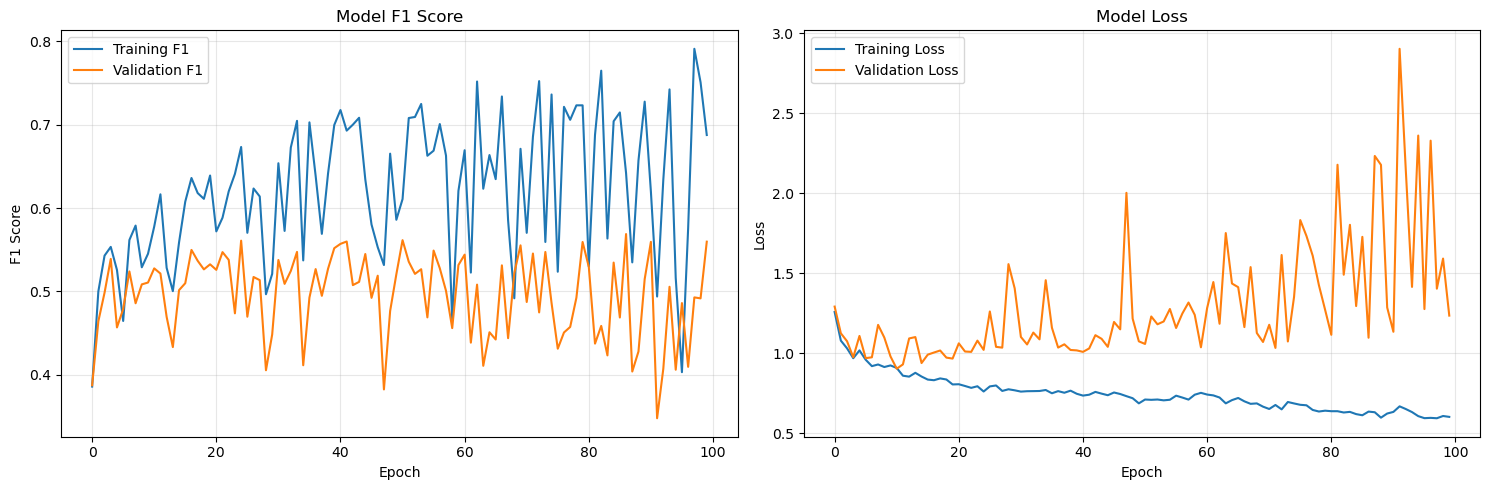

In [31]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# F1 Score
ax1.plot(history['train_f1'], label='Training F1')
ax1.plot(history['val_f1'], label='Validation F1')
ax1.set_title('Model F1 Score')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('F1 Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history['train_loss'], label='Training Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Load best model
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

def evaluate_model(model, data_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    return np.array(all_predictions), np.array(all_targets)

# Evaluate and print metrics
y_pred_train, y_true_train = evaluate_model(model, train_loader, device)
y_pred_val, y_true_val = evaluate_model(model, val_loader, device)
y_pred_test, y_true_test = evaluate_model(model, test_loader, device)

print(f"Training F1: {f1_score(y_true_train, y_pred_train, average='macro'):.4f}, Accuracy: {accuracy_score(y_true_train, y_pred_train):.4f}")
print(f"Validation F1: {f1_score(y_true_val, y_pred_val, average='macro'):.4f}, Accuracy: {accuracy_score(y_true_val, y_pred_val):.4f}")
print(f"Test F1: {f1_score(y_true_test, y_pred_test, average='macro'):.4f}, Accuracy: {accuracy_score(y_true_test, y_pred_test):.4f}")

Training F1: 0.6420, Accuracy: 0.6520
Validation F1: 0.5689, Accuracy: 0.5759
Test F1: 0.5704, Accuracy: 0.5777


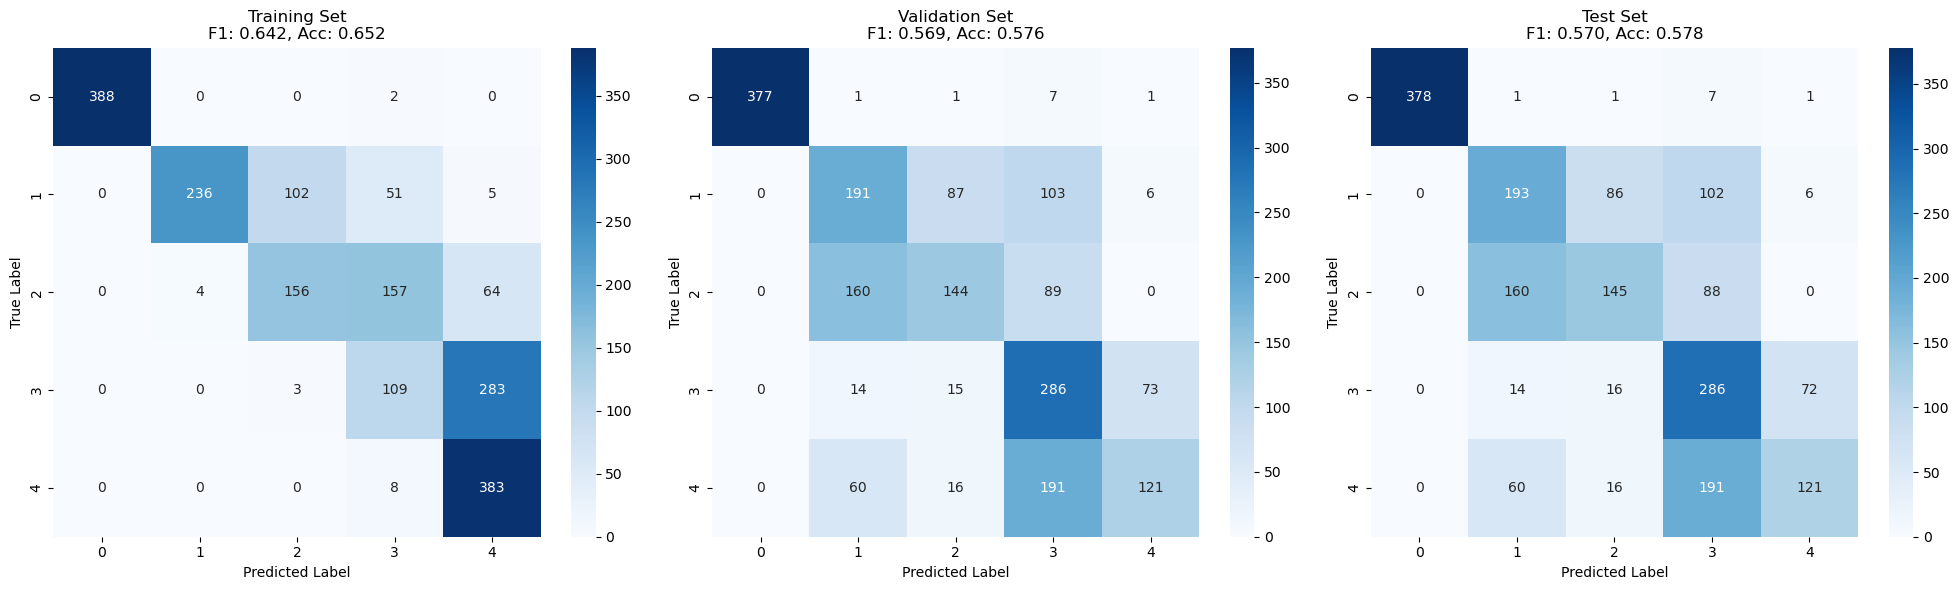

In [33]:
# Plot confusion matrices for all datasets
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

datasets = [
    (y_true_train, y_pred_train, "Training"),
    (y_true_val, y_pred_val, "Validation"), 
    (y_true_test, y_pred_test, "Test")
]

# Get all unique classes for consistent labeling
all_classes = sorted(np.unique(np.concatenate([y_train, y_val, y_test])))

for idx, (y_true, y_pred, title) in enumerate(datasets):
    cm = confusion_matrix(y_true, y_pred, labels=all_classes)
    
    # Calculate F1 score for this dataset
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=all_classes, yticklabels=all_classes)
    axes[idx].set_title(f'{title} Set\nF1: {f1:.3f}, Acc: {acc:.3f}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()


## 2D label visualization
Scatter plots of posx vs posy per split and class distributions.


Class distribution in Training set:
Label 0: 4607 samples (70.23%)
Label 1: 390 samples (5.95%)
Label 2: 395 samples (6.02%)
Label 3: 382 samples (5.82%)
Label 4: 395 samples (6.02%)
Label 5: 391 samples (5.96%)

Class distribution in Test set:
Label 0: 4613 samples (70.35%)
Label 1: 388 samples (5.92%)
Label 2: 387 samples (5.90%)
Label 3: 393 samples (5.99%)
Label 4: 388 samples (5.92%)
Label 5: 388 samples (5.92%)

Class distribution in Validation set:
Label 0: 4613 samples (70.35%)
Label 1: 388 samples (5.92%)
Label 2: 387 samples (5.90%)
Label 3: 393 samples (5.99%)
Label 4: 388 samples (5.92%)
Label 5: 388 samples (5.92%)


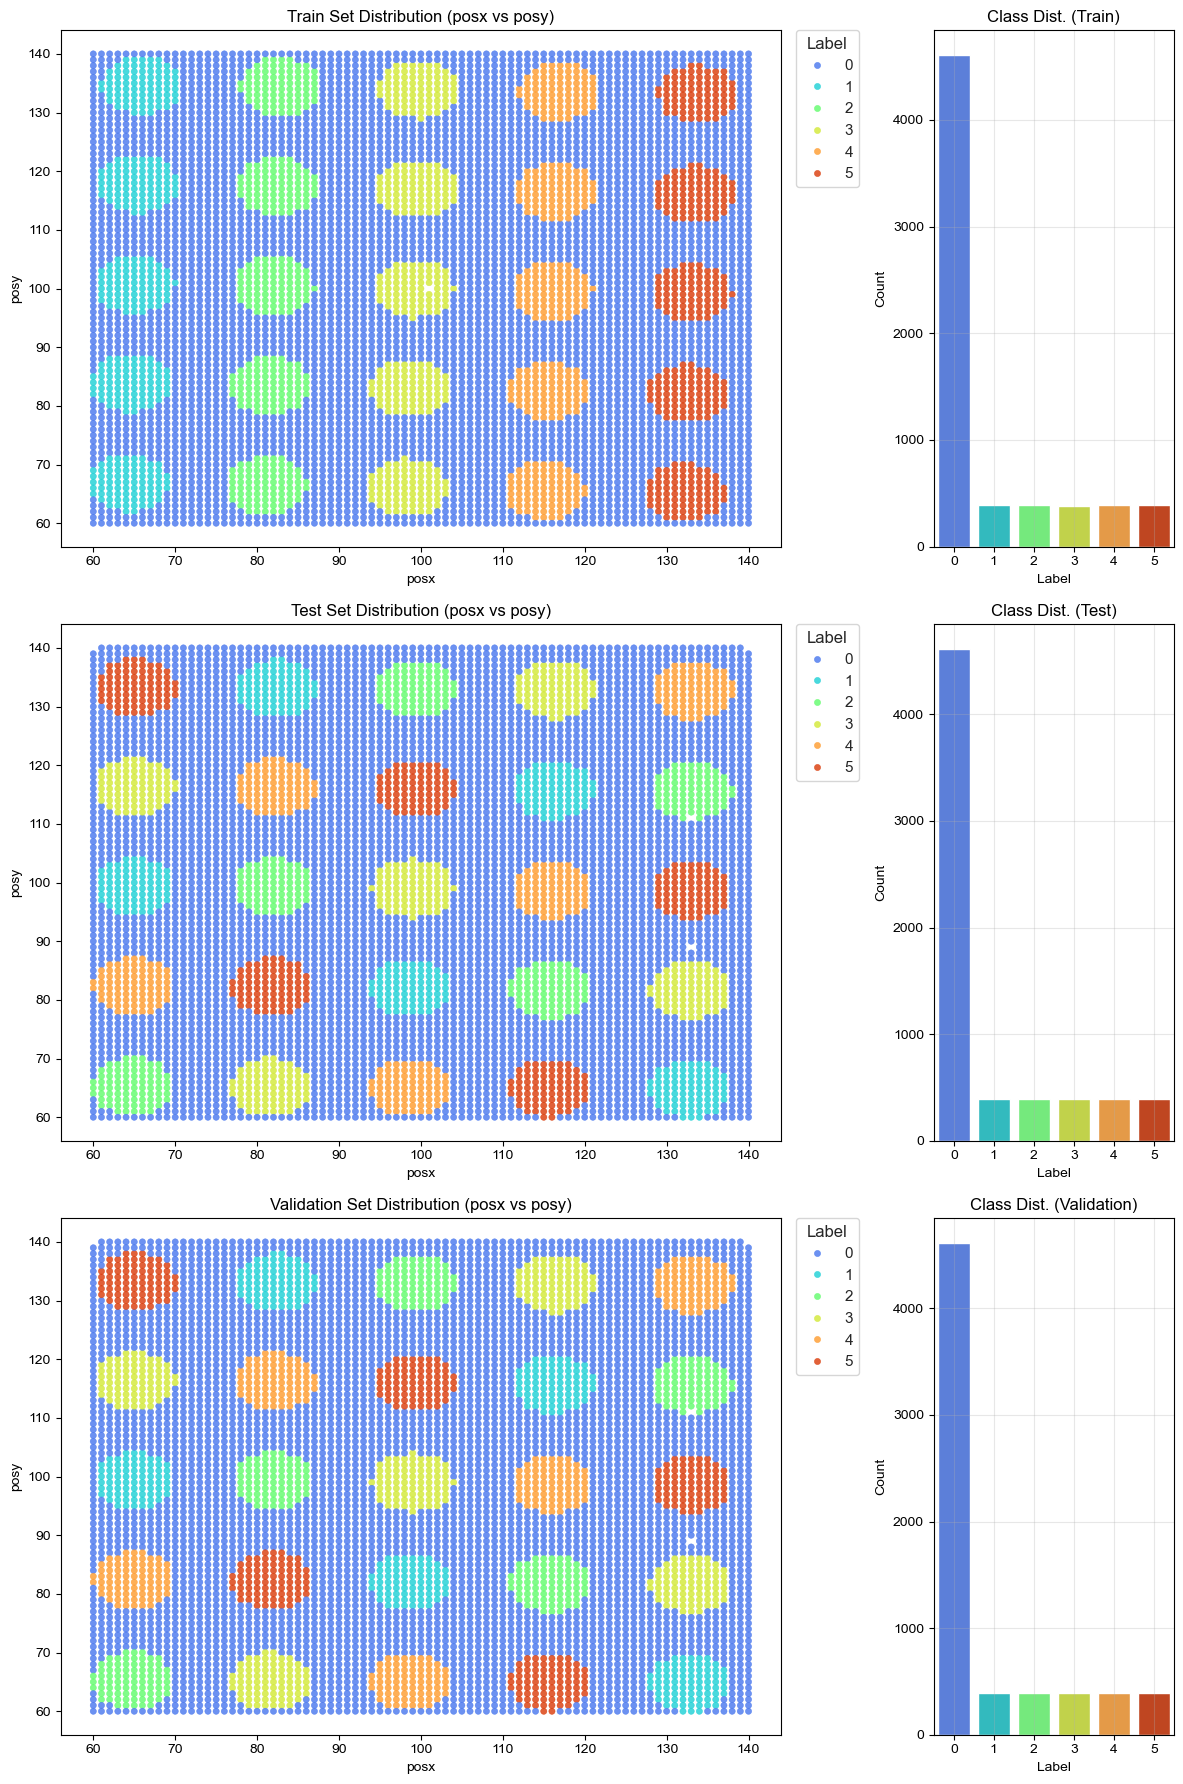

In [34]:
from collections import Counter

def plot_class_distribution(labels, ax, title, label_color_dict):
    counts = pd.Series(labels).value_counts().sort_index()
    colors = [label_color_dict.get(lbl, "#888888") for lbl in counts.index]
    sns.barplot(x=list(counts.index), y=list(counts.values), ax=ax, palette=colors)
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")

def visualize_datasets(data_train, data_test, data_val, label_column='label', x_col='posx', y_col='posy'):
    """Print class distribution and plot 2D scatter (x_col vs y_col) and per-split label histograms."""
    def print_class_distribution(dataset, name):
        dist = Counter(dataset[label_column])
        total = len(dataset)
        print(f"\nClass distribution in {name}:")
        for label, count in sorted(dist.items()):
            print(f"Label {label}: {count} samples ({count / total * 100:.2f}%)")

    # Print class distributions
    print_class_distribution(data_train, "Training set")
    print_class_distribution(data_test, "Test set")
    print_class_distribution(data_val, "Validation set")

    # Prepare plotting
    fig, axs = plt.subplots(3, 2, figsize=(12, 18), gridspec_kw={'width_ratios': [3, 1]})
    sns.set(style="whitegrid")

    # Consistent color palette across splits
    unique_labels = sorted(set(data_train[label_column]) | set(data_test[label_column]) | set(data_val[label_column]))
    palette_colors = sns.color_palette("turbo", n_colors=len(unique_labels))
    label_color_dict = {label: color for label, color in zip(unique_labels, palette_colors)}

    datasets = [
        ("Train", data_train, axs[0]),
        ("Test", data_test, axs[1]),
        ("Validation", data_val, axs[2])
    ]

    for title, data, (scatter_ax, hist_ax) in datasets:
        if x_col in data.columns and y_col in data.columns:
            sns.scatterplot(
                data=data, x=x_col, y=y_col, hue=label_column, palette=label_color_dict,
                ax=scatter_ax, alpha=0.8, s=20, edgecolor=None
            )
            scatter_ax.set_title(f"{title} Set Distribution ({x_col} vs {y_col})")
            scatter_ax.set_xlabel(x_col)
            scatter_ax.set_ylabel(y_col)
            scatter_ax.legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        else:
            scatter_ax.axis('off')
            missing = [c for c in [x_col, y_col] if c not in data.columns]
            scatter_ax.text(0.5, 0.5, f"Missing columns: {', '.join(missing)}", ha='center', va='center', transform=scatter_ax.transAxes)

        plot_class_distribution(data[label_column], hist_ax, f"Class Dist. ({title})", label_color_dict)
        hist_ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call the visualization with your desired columns; change x_col/y_col if needed
visualize_datasets(data_train, data_test, data_validation, label_column='label', x_col='posx', y_col='posy')